In [7]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

print("Loading datasets...")
# Using nrows=5000 for prototype speed. Remove to train on the full dataset.
df_accepted = pd.read_csv('/content/accepted_2007_to_2018Q4.csv', nrows=5000)
df_rejected = pd.read_csv('/content/rejected_2007_to_2018Q4.csv', nrows=5000)

print("Cleaning and merging data...")
acc_clean = pd.DataFrame({
    'loan_amnt': df_accepted['loan_amnt'],
    'risk_score': (df_accepted['fico_range_low'] + df_accepted['fico_range_high']) / 2,
    'dti': df_accepted['dti'],
    'state': df_accepted['addr_state'],
    'emp_length': df_accepted['emp_length'],
    'target': 1

})

rej_clean = pd.DataFrame({
    'loan_amnt': df_rejected['Amount Requested'],
    'risk_score': df_rejected['Risk_Score'],
    'dti': df_rejected['Debt-To-Income Ratio'].str.replace('%', '').astype(float),
    'state': df_rejected['State'],
    'emp_length': df_rejected['Employment Length'],
    'target': 0
})

df_merged = pd.concat([acc_clean, rej_clean], ignore_index=True)

# Standardize text and fill missing values
df_merged['emp_length'] = df_merged['emp_length'].replace({'< 1 year': '0 years'})
df_merged['emp_length'] = df_merged['emp_length'].astype(str).str.extract(r'(\d+)').astype(float)
df_merged = df_merged.dropna(subset=['loan_amnt', 'risk_score', 'dti'])
df_merged['emp_length'] = df_merged['emp_length'].fillna(df_merged['emp_length'].median())

# Encode and Scale
df_merged = pd.get_dummies(df_merged, columns=['state'], drop_first=True)
X = df_merged.drop('target', axis=1)
y = df_merged['target']

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Global Split
X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

x_test = X_test_global.values
y_test = y_test_global.values
input_shape = x_test.shape[1]

print(f"Data ready! Input shape for neural network: {input_shape}")

Loading datasets...
Cleaning and merging data...
Data ready! Input shape for neural network: 54


In [8]:
def create_non_iid_splits(X, y, num_banks, alpha=0.5):
    X_array = X.values
    y_array = y.values
    num_classes = len(np.unique(y_array))
    bank_indices = [[] for _ in range(num_banks)]

    for c in range(num_classes):
        idx_c = np.where(y_array == c)[0]
        np.random.shuffle(idx_c)
        proportions = np.random.dirichlet(np.repeat(alpha, num_banks))
        splits = (proportions * len(idx_c)).astype(int)
        splits[-1] = len(idx_c) - splits[:-1].sum()

        current_idx = 0
        for i in range(num_banks):
            bank_indices[i].extend(idx_c[current_idx : current_idx + splits[i]])
            current_idx += splits[i]

    client_X, client_y = [], []
    for indices in bank_indices:
        np.random.shuffle(indices)
        client_X.append(X_array[indices])
        client_y.append(y_array[indices])

    return client_X, client_y

# --- Configuration ---
NUM_BANKS = 5
ALPHA_VALUE = 0.5

print(f"Distributing data across {NUM_BANKS} banks (Non-IID Alpha={ALPHA_VALUE})...\n")
client_X, client_y = create_non_iid_splits(X_train_global, y_train_global, NUM_BANKS, ALPHA_VALUE)

# Verify the skew
for i in range(NUM_BANKS):
    unique, counts = np.unique(client_y[i], return_counts=True)
    dist = dict(zip(unique, counts))
    total_samples = sum(counts)
    pct_0 = (dist.get(0, 0) / total_samples) * 100 if total_samples > 0 else 0
    pct_1 = (dist.get(1, 0) / total_samples) * 100 if total_samples > 0 else 0

    print(f"Bank {i+1}: {total_samples} samples | Rejected: {pct_0:.1f}% | Accepted: {pct_1:.1f}%")

Distributing data across 5 banks (Non-IID Alpha=0.5)...

Bank 1: 2995 samples | Rejected: 58.4% | Accepted: 41.6%
Bank 2: 2510 samples | Rejected: 69.0% | Accepted: 31.0%
Bank 3: 910 samples | Rejected: 1.2% | Accepted: 98.8%
Bank 4: 463 samples | Rejected: 90.7% | Accepted: 9.3%
Bank 5: 1048 samples | Rejected: 1.3% | Accepted: 98.7%


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

def build_tabular_model(shape):
    """Dense Neural Network with Layer Normalization for FL stability."""
    model = keras.Sequential([
        layers.InputLayer(input_shape=(shape,)),

        layers.Dense(128, activation='relu'),
        layers.LayerNormalization(), # FIX: Replaced BatchNormalization
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.LayerNormalization(), # FIX: Replaced BatchNormalization
        layers.Dropout(0.2),

        layers.Dense(32, activation='relu'),
        layers.LayerNormalization(), # FIX: Replaced BatchNormalization

        layers.Dense(1, activation='sigmoid')
    ])
    return model

def fed_att_aggregation(global_weights, local_weights_list, step_size=1.0):
    """
    Attention-based Federated Aggregation (FedAtt).
    Calculates attention scores based on the distance between local and global weights.
    """
    new_global_weights = [np.zeros_like(w) for w in global_weights]

    # Calculate the distance (L2 norm) between each local model and the global model
    distances = []
    for local_weights in local_weights_list:
        dist = 0.0
        for lw, gw in zip(local_weights, global_weights):
            dist += np.linalg.norm(lw - gw)
        distances.append(dist)

    # Convert distances to Attention Scores using Softmax
    # FIX: Added 1e-9 to prevent division by zero or NaN issues
    distances = np.array(distances)
    attention_scores = np.exp(-distances) / (np.sum(np.exp(-distances)) + 1e-9)

    # Aggregate weights using the attention scores
    for local_weights, score in zip(local_weights_list, attention_scores):
        for i, lw in enumerate(local_weights):
            # The update is scaled by the attention score
            new_global_weights[i] += score * lw

    # Apply the step size (similar to a server-side learning rate)
    final_weights = []
    for i in range(len(global_weights)):
        final_weights.append(global_weights[i] + step_size * (new_global_weights[i] - global_weights[i]))

    return final_weights, attention_scores


def local_train_secure_compressed(model, global_weights, X_local, y_local,
                                  epochs, batch_size, mu, l2_norm_clip, noise_multiplier, learning_rate, compression_threshold=1e-6):
    """
    Custom training loop implementing FedProx, Differential Privacy, AND Gradient Compression.
    """
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    loss_fn = tf.keras.losses.BinaryCrossentropy()

    # Isolate trainable weights to prevent Normalization crash during FedProx
    global_trainable = [w for w, t in zip(global_weights, model.weights) if t.trainable]

    dataset = tf.data.Dataset.from_tensor_slices((X_local, y_local)).batch(batch_size)

    for epoch in range(epochs):
        for step, (x_batch, y_batch) in enumerate(dataset):
            with tf.GradientTape() as tape:
                y_pred = model(x_batch, training=True)
                base_loss = loss_fn(y_batch, y_pred)

                # 1. FedProx Penalty
                proximal_term = 0.0
                for local_weight, global_weight in zip(model.trainable_variables, global_trainable):
                    proximal_term += tf.reduce_sum(tf.square(local_weight - global_weight))

                total_loss = base_loss + (mu / 2.0) * proximal_term

            gradients = tape.gradient(total_loss, model.trainable_variables)

            # 2. Differential Privacy & 3. Gradient Compression
            final_gradients = []
            for grad in gradients:
                if grad is None:
                    final_gradients.append(None)
                    continue

                # A. Apply Differential Privacy
                clipped_grad = tf.clip_by_norm(grad, l2_norm_clip)
                noise = tf.random.normal(tf.shape(clipped_grad), mean=0.0,
                                         stddev=(noise_multiplier * l2_norm_clip))
                dp_grad = clipped_grad + noise

                # B. Apply Gradient Compression (Sparsification)
                mask = tf.math.abs(dp_grad) > compression_threshold
                compressed_grad = tf.where(mask, dp_grad, tf.zeros_like(dp_grad))

                final_gradients.append(compressed_grad)

            # Apply the compressed, private gradients
            optimizer.apply_gradients(zip(final_gradients, model.trainable_variables))

    return model.get_weights()

print("FedAtt Aggregation, Secure Training (DP/FedProx), and Gradient Compression Engines defined.")

FedAtt Aggregation, Secure Training (DP/FedProx), and Gradient Compression Engines defined.


In [ ]:
# Initialize the Global Model
global_model = build_tabular_model(input_shape)
global_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
global_weights = global_model.get_weights()

# --- Federated Learning Hyperparameters ---
FL_ROUNDS = 10
LOCAL_EPOCHS = 2
LOCAL_BATCH_SIZE = 32
LEARNING_RATE = 0.005

# --- Security & Stability Hyperparameters ---
MU = 0.001             # FIX: Lowered significantly to let the models learn freely
CLIP_NORM = 1.0
NOISE_MULT = 0.001
COMP_THRESH = 1e-6     # FIX: Drastically lowered to ensure gradients survive the compression

print("STARTING SECURE FEDERATED LEARNING (FedAtt + DP + Compression)")

for round_num in range(1, FL_ROUNDS + 1):
    print(f"--- Communication Round {round_num}/{FL_ROUNDS} ---")
    local_weights_collected = []

    for bank_id in range(NUM_BANKS):
        local_model = build_tabular_model(input_shape)
        local_model.set_weights(global_weights)

        updated_weights = local_train_secure_compressed(
            model=local_model,
            global_weights=global_weights,
            X_local=client_X[bank_id],
            y_local=client_y[bank_id],
            epochs=LOCAL_EPOCHS,
            batch_size=LOCAL_BATCH_SIZE,
            mu=MU,
            l2_norm_clip=CLIP_NORM,
            noise_multiplier=NOISE_MULT,
            learning_rate=LEARNING_RATE,
            compression_threshold=COMP_THRESH
        )

        local_weights_collected.append(updated_weights)
        tf.keras.backend.clear_session()

    # Server aggregates weights via the smart FedAtt algorithm
    global_weights, att_scores = fed_att_aggregation(global_weights, local_weights_collected)

    global_model.set_weights(global_weights)
    loss, accuracy = global_model.evaluate(x_test, y_test, verbose=0)

    print(f"> Global Model Accuracy: {accuracy:.4f} | Loss: {loss:.4f}\n")

print("Secure Federated Learning Prototype Complete!")

STARTING SECURE FEDERATED LEARNING (FedAtt + DP + Compression)

--- Communication Round 1/10 ---
> Global Model Accuracy: 0.6912 | Loss: 0.6072

--- Communication Round 2/10 ---
> Global Model Accuracy: 0.5449 | Loss: 0.8883

--- Communication Round 3/10 ---
> Global Model Accuracy: 0.5994 | Loss: 0.9024

--- Communication Round 4/10 ---
> Global Model Accuracy: 0.5363 | Loss: 1.0853

--- Communication Round 5/10 ---
> Global Model Accuracy: 0.5474 | Loss: 1.1744

--- Communication Round 6/10 ---
> Global Model Accuracy: 0.5671 | Loss: 1.3021

--- Communication Round 7/10 ---
> Global Model Accuracy: 0.5807 | Loss: 1.1317

--- Communication Round 8/10 ---
> Global Model Accuracy: 0.5550 | Loss: 1.4022

--- Communication Round 9/10 ---
> Global Model Accuracy: 0.5646 | Loss: 1.1049

--- Communication Round 10/10 ---
> Global Model Accuracy: 0.5716 | Loss: 1.2971

Secure Federated Learning Prototype Complete!


TASK : GLOBAL MODEL EVALUATION & METRICS



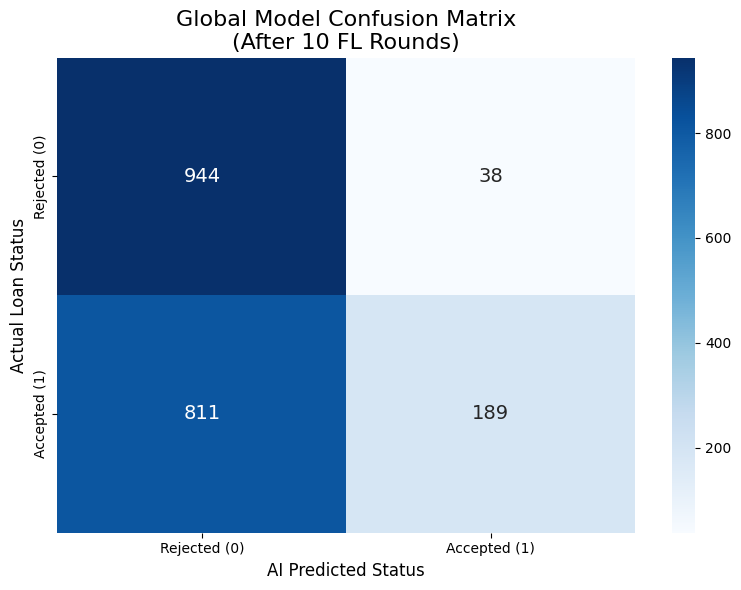


--- Detailed Classification Report ---
              precision    recall  f1-score   support

Rejected (0)       0.54      0.96      0.69       982
Accepted (1)       0.83      0.19      0.31      1000

    accuracy                           0.57      1982
   macro avg       0.69      0.58      0.50      1982
weighted avg       0.69      0.57      0.50      1982



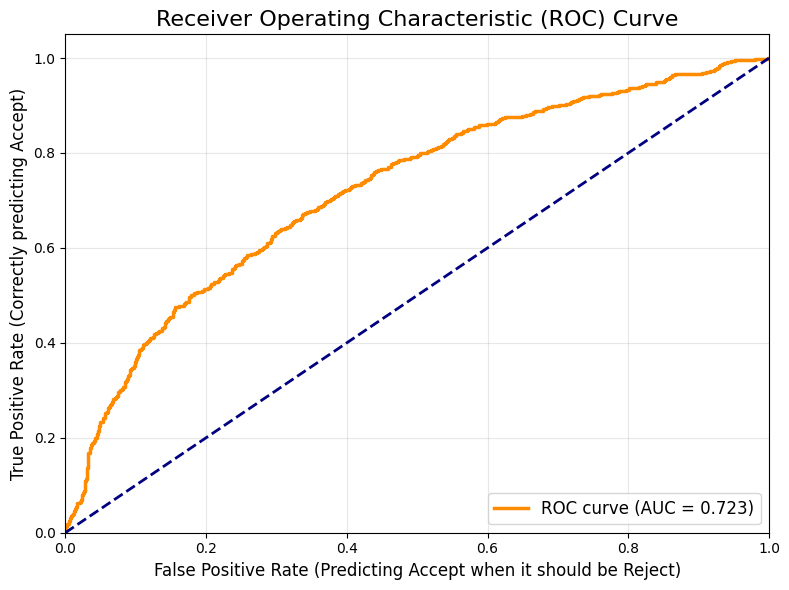

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print("TASK : GLOBAL MODEL EVALUATION & METRICS")

# Get global model predictions on the unseen global test set
y_pred_probs = global_model.predict(x_test, verbose=0)
# Convert probabilities to binary predictions (using 0.5 as the cutoff)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# 1. THE CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Accepted (1)'],
            yticklabels=['Rejected (0)', 'Accepted (1)'],
            annot_kws={"size": 14})
plt.title('Global Model Confusion Matrix\n(After 10 FL Rounds)', fontsize=16)
plt.ylabel('Actual Loan Status', fontsize=12)
plt.xlabel('AI Predicted Status', fontsize=12)
plt.tight_layout()
plt.show()

# 2. PRECISION, RECALL, & F1-SCORE
print("\n--- Detailed Classification Report ---")
# This prints the exact metrics that matter for highly skewed FL Evaluation
print(classification_report(y_test, y_pred_classes, target_names=['Rejected (0)', 'Accepted (1)']))

# 3. ROC CURVE & AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Predicting Accept when it should be Reject)', fontsize=12)
plt.ylabel('True Positive Rate (Correctly predicting Accept)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
print("TASK: THE COLD START SIMULATION (Solving Gap 5)")

# 1. Simulate a brand new bank (Bank 6) with only 50 historical loan applications
new_bank_X = x_test[:50]
new_bank_y = y_test[:50]

# 2. Isolate 200 completely unseen records to test if the models actually work
# We use data from index 50 to 250 so it doesn't overlap with Bank 6's training data
unseen_eval_X = x_test[50:250]
unseen_eval_y = y_test[50:250]

# SCENARIO A: Bank 6 builds an AI from scratch (The Problem)
print("Scenario A: Bank 6 tries to train a model from scratch with only 50 records...")
scratch_model = build_tabular_model(input_shape)
scratch_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train for 5 epochs on the tiny dataset
scratch_model.fit(new_bank_X, new_bank_y, epochs=5, batch_size=8, verbose=0)
_, scratch_acc = scratch_model.evaluate(unseen_eval_X, unseen_eval_y, verbose=0)
print(f"❌ Scratch Model Accuracy: {scratch_acc:.4f} (Likely terrible/overfitted)\n")

# SCENARIO B: Zero-Shot Transfer (Downloading our Global Model)
print("Scenario B: Bank 6 downloads our Pre-Trained Global Model (Zero-Shot)...")
# We test the global model on the unseen data without any additional training
_, global_acc = global_model.evaluate(unseen_eval_X, unseen_eval_y, verbose=0)
print(f"✅ Out-of-the-Box Global Accuracy: {global_acc:.4f} (Instant capability!)\n")

# SCENARIO C: Few-Shot Fine-Tuning (The Ultimate Solution)
print("Scenario C: Bank 6 fine-tunes the Global Model using their 50 local records...")
# Clone the model so we don't accidentally alter the actual global weights on the central server
finetuned_model = keras.models.clone_model(global_model)
finetuned_model.set_weights(global_model.get_weights())
finetuned_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fine-tune the pre-trained weights for just 3 epochs using a small batch size
finetuned_model.fit(new_bank_X, new_bank_y, epochs=3, batch_size=8, verbose=0)
_, ft_acc = finetuned_model.evaluate(unseen_eval_X, unseen_eval_y, verbose=0)
print(f"🚀 Fine-Tuned Global Accuracy: {ft_acc:.4f} (The Cold Start is solved!)\n")

TASK: THE COLD START SIMULATION (Solving Gap 5)

Scenario A: Bank 6 tries to train a model from scratch with only 50 records...
❌ Scratch Model Accuracy: 0.6050 (Likely terrible/overfitted)

Scenario B: Bank 6 downloads our Pre-Trained Global Model (Zero-Shot)...
✅ Out-of-the-Box Global Accuracy: 0.5900 (Instant capability!)

Scenario C: Bank 6 fine-tunes the Global Model using their 50 local records...
🚀 Fine-Tuned Global Accuracy: 0.7500 (The Cold Start is solved!)



In [ ]:
import tensorflow as tf
from tensorflow import keras

def run_federated_experiment(X_train, y_train, X_test, y_test, num_banks, fl_rounds, local_epochs, mu, noise_mult, comp_thresh, learning_rate):
    """
    Runs a complete federated learning experiment with specified parameters.
    """
    # Create non-IID splits for the current number of banks
    client_X, client_y = create_non_iid_splits(X_train, y_train, num_banks, ALPHA_VALUE)

    # Initialize the Global Model
    global_model = build_tabular_model(input_shape)
    global_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    global_weights = global_model.get_weights()

    # --- Federated Learning Loop ---
    for round_num in range(1, fl_rounds + 1):
        local_weights_collected = []

        for bank_id in range(num_banks):
            local_model = build_tabular_model(input_shape)
            local_model.set_weights(global_weights)

            updated_weights = local_train_secure_compressed(
                model=local_model,
                global_weights=global_weights,
                X_local=client_X[bank_id],
                y_local=client_y[bank_id],
                epochs=local_epochs,
                batch_size=LOCAL_BATCH_SIZE,
                mu=mu,
                l2_norm_clip=CLIP_NORM,
                noise_multiplier=noise_mult,
                learning_rate=learning_rate,
                compression_threshold=comp_thresh
            )
            local_weights_collected.append(updated_weights)
            tf.keras.backend.clear_session()

        # Server aggregates weights via the smart FedAtt algorithm
        global_weights, _ = fed_att_aggregation(global_weights, local_weights_collected)

        global_model.set_weights(global_weights)

    return global_model

print("STARTING MULTI-MODEL EXPERIMENT TRACKER")

# 1. Create a dictionary to store all models and their stats
experiment_results = {}

# 2. Define the setups you want to test: {"banks": Num, "epochs": Num, "rounds": Num}
setups_to_test = [
    {"banks": 3, "epochs": 1, "rounds": 5},   # Fast Baseline
    {"banks": 5, "epochs": 2, "rounds": 10},  # Core Prototype (The one you already proved)
    {"banks": 10, "epochs": 2, "rounds": 10}  # High Decentralization (Testing the limits)
]

# 3. Run the loop to train and name them dynamically
for setup in setups_to_test:
    b = setup["banks"]
    e = setup["epochs"]
    r = setup["rounds"]

    # Generate the dynamic name
    model_name = f"Model_{b}Banks_{e}Epochs"
    print(f"\n>>> Running Experiment: {model_name} <<<")

    # Train the model using your master function
    trained_model = run_federated_experiment(
        X_train=X_train_global, y_train=y_train_global,
        X_test=x_test, y_test=y_test,
        num_banks=b, fl_rounds=r, local_epochs=e,
        mu=0.001, noise_mult=0.001, comp_thresh=1e-6, learning_rate=0.005
    )

    # Evaluate the model on the unseen test data
    loss, acc = trained_model.evaluate(x_test, y_test, verbose=0)

    # Save the model and its score into the dictionary
    experiment_results[model_name] = {
        "model": trained_model,
        "accuracy": acc,
        "loss": loss
    }

# 4. Print the Final Leaderboard for your report
print("FINAL EXPERIMENT LEADERBOARD")
for name, results in experiment_results.items():
    print(f"{name} -> Accuracy: {results['accuracy']:.4f} | Loss: {results['loss']:.4f}")

STARTING MULTI-MODEL EXPERIMENT TRACKER


>>> Running Experiment: Model_3Banks_1Epochs <<<

>>> Running Experiment: Model_5Banks_2Epochs <<<

>>> Running Experiment: Model_10Banks_2Epochs <<<

FINAL EXPERIMENT LEADERBOARD
Model_3Banks_1Epochs -> Accuracy: 0.7114 | Loss: 0.6179
Model_5Banks_2Epochs -> Accuracy: 0.5045 | Loss: 4.9955
Model_10Banks_2Epochs -> Accuracy: 0.6206 | Loss: 1.2816
